<a href="https://colab.research.google.com/github/SHASHANK8412/IRIS/blob/main/Ensemble_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Write a program that demonstrates the advantage of ensemble learning compared to a
#single classifier.
#Apply a Decision Tree and a Random Forest (RF) classifier on a given dataset.
#Compare their performance using evaluation metrics such as accuracy, precision, recall,
#and F1-score.
#Explore the effect of changing the number of estimators (decision trees) in Random
#Forest. Write clear observations with justification.
# Import required libraries
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 1. Load the Breast Cancer dataset
data = load_breast_cancer()
X = data.data
y = data.target

# 2. Split dataset into training and testing sets (70%-30%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. Single classifier: Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

# 4. Ensemble classifier: Random Forest with default 100 estimators
rf = RandomForestClassifier(random_state=42, n_estimators=100)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# 5. Function to display evaluation metrics
def evaluate_model(y_true, y_pred, model_name):
    print(f"--- {model_name} Performance ---")
    print(f"Accuracy : {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall   : {recall_score(y_true, y_pred):.4f}")
    print(f"F1-score : {f1_score(y_true, y_pred):.4f}")
    print("-------------------------------\n")

# 6. Evaluate both models
evaluate_model(y_test, y_pred_dt, "Decision Tree")
evaluate_model(y_test, y_pred_rf, "Random Forest (100 trees)")

# 7. Explore effect of changing number of estimators in Random Forest
estimators_list = [10, 50, 100, 200, 500]
print("Effect of number of trees on Random Forest performance:\n")
for n in estimators_list:
    rf_temp = RandomForestClassifier(n_estimators=n, random_state=42)
    rf_temp.fit(X_train, y_train)
    y_pred_temp = rf_temp.predict(X_test)
    print(f"Number of Trees: {n}")
    print(f"Accuracy: {accuracy_score(y_test, y_pred_temp):.4f}")
    print(f"F1-score: {f1_score(y_test, y_pred_temp):.4f}\n")


--- Decision Tree Performance ---
Accuracy : 0.9415
Precision: 0.9712
Recall   : 0.9352
F1-score : 0.9528
-------------------------------

--- Random Forest (100 trees) Performance ---
Accuracy : 0.9708
Precision: 0.9640
Recall   : 0.9907
F1-score : 0.9772
-------------------------------

Effect of number of trees on Random Forest performance:

Number of Trees: 10
Accuracy: 0.9649
F1-score: 0.9722

Number of Trees: 50
Accuracy: 0.9708
F1-score: 0.9772

Number of Trees: 100
Accuracy: 0.9708
F1-score: 0.9772

Number of Trees: 200
Accuracy: 0.9708
F1-score: 0.9772

Number of Trees: 500
Accuracy: 0.9708
F1-score: 0.9772



In [ ]:
# Write a program that demonstrates the use of simple ensemble techniques: Max Voting,
# Average Voting, and Weighted Average Voting (assign weights based on each model’s
# performance).
# Apply these techniques on a suitable dataset and compare results.

# Import libraries
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 1. Load dataset
data = load_breast_cancer()
X = data.data
y = data.target

# 2. Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. Train individual models
dt = DecisionTreeClassifier(random_state=42)
rf = RandomForestClassifier(random_state=42, n_estimators=100)
lr = LogisticRegression(max_iter=1000, random_state=42)

models = [dt, rf, lr]

# Fit models
for model in models:
    model.fit(X_train, y_train)

# 4. Get predictions
y_pred_dt = dt.predict(X_test)
y_pred_rf = rf.predict(X_test)
y_pred_lr = lr.predict(X_test)

# 5. Evaluation function
def evaluate(y_true, y_pred, model_name):
    print(f"--- {model_name} ---")
    print(f"Accuracy : {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall   : {recall_score(y_true, y_pred):.4f}")
    print(f"F1-score : {f1_score(y_true, y_pred):.4f}\n")

# Evaluate individual models
evaluate(y_test, y_pred_dt, "Decision Tree")
evaluate(y_test, y_pred_rf, "Random Forest")
evaluate(y_test, y_pred_lr, "Logistic Regression")

# ---------------------------
# 6. Ensemble Techniques
# ---------------------------

# a) Max Voting (Hard Voting)
preds = np.array([y_pred_dt, y_pred_rf, y_pred_lr])
y_pred_hard = np.apply_along_axis(lambda x: np.bincount(x).argmax(), axis=0, arr=preds)
evaluate(y_test, y_pred_hard, "Hard Voting (Max Voting)")

# b) Average Voting (Soft Voting)
proba_dt = dt.predict_proba(X_test)
proba_rf = rf.predict_proba(X_test)
proba_lr = lr.predict_proba(X_test)

avg_proba = (proba_dt + proba_rf + proba_lr) / 3
y_pred_soft = np.argmax(avg_proba, axis=1)
evaluate(y_test, y_pred_soft, "Soft Voting (Average)")

# c) Weighted Average Voting
# Assign weights based on individual model accuracy on training set
train_acc = [accuracy_score(y_train, dt.predict(X_train)),
             accuracy_score(y_train, rf.predict(X_train)),
             accuracy_score(y_train, lr.predict(X_train))]

# Normalize weights to sum = 1
weights = np.array(train_acc) / np.sum(train_acc)
weighted_proba = (proba_dt * weights[0] + proba_rf * weights[1] + proba_lr * weights[2])
y_pred_weighted = np.argmax(weighted_proba, axis=1)
evaluate(y_test, y_pred_weighted, "Weighted Average Voting")


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


--- Decision Tree ---
Accuracy : 0.9415
Precision: 0.9712
Recall   : 0.9352
F1-score : 0.9528

--- Random Forest ---
Accuracy : 0.9708
Precision: 0.9640
Recall   : 0.9907
F1-score : 0.9772

--- Logistic Regression ---
Accuracy : 0.9708
Precision: 0.9725
Recall   : 0.9815
F1-score : 0.9770

--- Hard Voting (Max Voting) ---
Accuracy : 0.9825
Precision: 0.9817
Recall   : 0.9907
F1-score : 0.9862

--- Soft Voting (Average) ---
Accuracy : 0.9825
Precision: 0.9817
Recall   : 0.9907
F1-score : 0.9862

--- Weighted Average Voting ---
Accuracy : 0.9825
Precision: 0.9817
Recall   : 0.9907
F1-score : 0.9862



In [ ]:
# Write a program to show the difference between Hard Voting and Soft Voting classifiers
# in ensemble learning using multiple base learners (e.g., Decision Tree, Logistic
# Regression, and KNN).



# Import libraries
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 1. Load dataset
data = load_breast_cancer()
X = data.data
y = data.target

# 2. Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. Initialize base learners
dt = DecisionTreeClassifier(random_state=42)
lr = LogisticRegression(max_iter=1000, random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)

# --------------------------
# 4. Hard Voting Classifier
# --------------------------
hard_voting_clf = VotingClassifier(
    estimators=[('DecisionTree', dt), ('LogisticRegression', lr), ('KNN', knn)],
    voting='hard'  # Hard Voting
)
hard_voting_clf.fit(X_train, y_train)
y_pred_hard = hard_voting_clf.predict(X_test)

# --------------------------
# 5. Soft Voting Classifier
# --------------------------
soft_voting_clf = VotingClassifier(
    estimators=[('DecisionTree', dt), ('LogisticRegression', lr), ('KNN', knn)],
    voting='soft'  # Soft Voting
)
soft_voting_clf.fit(X_train, y_train)
y_pred_soft = soft_voting_clf.predict(X_test)

# --------------------------
# 6. Evaluation function
# --------------------------
def evaluate(y_true, y_pred, model_name):
    print(f"--- {model_name} ---")
    print(f"Accuracy : {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall   : {recall_score(y_true, y_pred):.4f}")
    print(f"F1-score : {f1_score(y_true, y_pred):.4f}\n")

# Evaluate Hard Voting
evaluate(y_test, y_pred_hard, "Hard Voting Classifier")

# Evaluate Soft Voting
evaluate(y_test, y_pred_soft, "Soft Voting Classifier")


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


--- Hard Voting Classifier ---
Accuracy : 0.9766
Precision: 0.9727
Recall   : 0.9907
F1-score : 0.9817

--- Soft Voting Classifier ---
Accuracy : 0.9825
Precision: 0.9817
Recall   : 0.9907
F1-score : 0.9862



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
# Write a program to explore the Bagging technique using the RandomForestClassifier on a
# suitable dataset.
# Experiment with parameters such as number of estimators, maximum depth, and random
# state.
# Write detailed observations and justify the changes in model performance.


# Import required libraries
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 1. Load the Breast Cancer dataset
data = load_breast_cancer()
X = data.data
y = data.target

# 2. Split the dataset into training and testing sets (70%-30%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. Function to train Random Forest and evaluate performance
def evaluate_rf(n_estimators=100, max_depth=None, random_state=42):
    rf = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth, random_state=random_state)
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)

    print(f"Random Forest (n_estimators={n_estimators}, max_depth={max_depth}, random_state={random_state})")
    print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred):.4f}")
    print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
    print(f"F1-score : {f1_score(y_test, y_pred):.4f}\n")

# -------------------------------
# 4. Experiment with number of estimators
# -------------------------------
print("----- Experiment: Number of Estimators -----\n")
for n in [10, 50, 100, 200, 500]:
    evaluate_rf(n_estimators=n)

# -------------------------------
# 5. Experiment with maximum depth
# -------------------------------
print("----- Experiment: Maximum Depth -----\n")
for depth in [None, 2, 5, 10, 20]:
    evaluate_rf(n_estimators=100, max_depth=depth)

# -------------------------------
# 6. Experiment with random states
# -------------------------------
print("----- Experiment: Random State -----\n")
for state in [0, 42, 100, 200]:
    evaluate_rf(n_estimators=100, max_depth=None, random_state=state)


----- Experiment: Number of Estimators -----

Random Forest (n_estimators=10, max_depth=None, random_state=42)
Accuracy : 0.9649
Precision: 0.9722
Recall   : 0.9722
F1-score : 0.9722

Random Forest (n_estimators=50, max_depth=None, random_state=42)
Accuracy : 0.9708
Precision: 0.9640
Recall   : 0.9907
F1-score : 0.9772

Random Forest (n_estimators=100, max_depth=None, random_state=42)
Accuracy : 0.9708
Precision: 0.9640
Recall   : 0.9907
F1-score : 0.9772

Random Forest (n_estimators=200, max_depth=None, random_state=42)
Accuracy : 0.9708
Precision: 0.9640
Recall   : 0.9907
F1-score : 0.9772

Random Forest (n_estimators=500, max_depth=None, random_state=42)
Accuracy : 0.9708
Precision: 0.9640
Recall   : 0.9907
F1-score : 0.9772

----- Experiment: Maximum Depth -----

Random Forest (n_estimators=100, max_depth=None, random_state=42)
Accuracy : 0.9708
Precision: 0.9640
Recall   : 0.9907
F1-score : 0.9772

Random Forest (n_estimators=100, max_depth=2, random_state=42)
Accuracy : 0.9532
Pr

In [1]:
#Write a program using the RandomForestRegressor model to make predictions on asuitable regression dataset.
#Enable and observe the oob_score (Out-of-Bag score) parameter.
#Interpret the results and explain its significance.

# Step 1: Import required libraries
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Step 2: Load the California housing dataset
housing = fetch_california_housing()
X = housing.data
y = housing.target

# Step 3: Split the dataset into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 4: Create RandomForestRegressor with OOB scoring enabled
rf_model = RandomForestRegressor(
    n_estimators=100,  # Number of trees
    oob_score=True,    # Enable Out-of-Bag score
    random_state=42
)

# Step 5: Train the model
rf_model.fit(X_train, y_train)

# Step 6: Make predictions on the test set
y_pred = rf_model.predict(X_test)

# Step 7: Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
oob_score = rf_model.oob_score_

# Step 8: Display results
print("Mean Squared Error (Test set):", mse)
print("R^2 Score (Test set):", r2)
print("OOB Score (Training set):", oob_score)


Mean Squared Error (Test set): 0.2553684927247781
R^2 Score (Test set): 0.8051230593157366
OOB Score (Training set): 0.8074158009726365


In [4]:
#Write a program to explore different Boosting techniques using suitable datasets:
#Adaptive Boosting (AdaBoost) – binary classification,
#Gradient Boosting – classification and regression,
#XGBoost,
#CatBoost.

# Step 1: Import necessary libraries
from sklearn.datasets import make_classification, make_regression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier, GradientBoostingRegressor
import xgboost as xgb
from catboost import CatBoostClassifier, CatBoostRegressor
import numpy as np

# ==============================
# 1. AdaBoost - Binary Classification
# ==============================
# Dataset: synthetic binary classification
X_cls, y_cls = make_classification(n_samples=1000, n_features=20, n_informative=15,
                                   n_redundant=5, random_state=42)
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(X_cls, y_cls, test_size=0.2, random_state=42)

# AdaBoost classifier
ada_model = AdaBoostClassifier(n_estimators=50, learning_rate=1.0, random_state=42)
ada_model.fit(X_train_cls, y_train_cls)
y_pred_ada = ada_model.predict(X_test_cls)

print("=== AdaBoost (Binary Classification) ===")
print("Accuracy:", accuracy_score(y_test_cls, y_pred_ada))

# Observation: AdaBoost focuses on samples that were misclassified by previous weak learners, improving accuracy iteratively.

# ==============================
# 2. Gradient Boosting - Classification
# ==============================
gbc_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gbc_model.fit(X_train_cls, y_train_cls)
y_pred_gbc = gbc_model.predict(X_test_cls)

print("\n=== Gradient Boosting (Classification) ===")
print("Accuracy:", accuracy_score(y_test_cls, y_pred_gbc))

# Observation: Gradient Boosting minimizes a loss function (like log-loss) iteratively, correcting previous errors more smoothly than AdaBoost.

# ==============================
# 3. Gradient Boosting - Regression
# ==============================
X_reg, y_reg = make_regression(n_samples=1000, n_features=20, noise=10, random_state=42)
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

gbr_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gbr_model.fit(X_train_reg, y_train_reg)
y_pred_gbr = gbr_model.predict(X_test_reg)

print("\n=== Gradient Boosting (Regression) ===")
print("MSE:", mean_squared_error(y_test_reg, y_pred_gbr))
print("R2 Score:", r2_score(y_test_reg, y_pred_gbr))

# Observation: Gradient Boosting reduces residual errors iteratively, improving regression predictions over iterations.

# ==============================
# 4. XGBoost - Classification & Regression
# ==============================
# Classification
xgb_cls = xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_cls.fit(X_train_cls, y_train_cls)
y_pred_xgb_cls = xgb_cls.predict(X_test_cls)

print("\n=== XGBoost (Classification) ===")
print("Accuracy:", accuracy_score(y_test_cls, y_pred_xgb_cls))

# Regression
xgb_reg = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
xgb_reg.fit(X_train_reg, y_train_reg)
y_pred_xgb_reg = xgb_reg.predict(X_test_reg)

print("\n=== XGBoost (Regression) ===")
print("MSE:", mean_squared_error(y_test_reg, y_pred_xgb_reg))
print("R2 Score:", r2_score(y_test_reg, y_pred_xgb_reg))

# Observation: XGBoost adds regularization and weighted updates, preventing overfitting and improving both classification and regression iteratively.

# ==============================
# 5. CatBoost - Classification & Regression
# ==============================
# Classification
cat_cls = CatBoostClassifier(iterations=100, learning_rate=0.1, depth=3, verbose=0, random_state=42)
cat_cls.fit(X_train_cls, y_train_cls)
y_pred_cat_cls = cat_cls.predict(X_test_cls)

print("\n=== CatBoost (Classification) ===")
print("Accuracy:", accuracy_score(y_test_cls, y_pred_cat_cls))

# Regression
cat_reg = CatBoostRegressor(iterations=100, learning_rate=0.1, depth=3, verbose=0, random_state=42)
cat_reg.fit(X_train_reg, y_train_reg)
y_pred_cat_reg = cat_reg.predict(X_test_reg)

print("\n=== CatBoost (Regression) ===")
print("MSE:", mean_squared_error(y_test_reg, y_pred_cat_reg))
print("R2 Score:", r2_score(y_test_reg, y_pred_cat_reg))

# Observation: CatBoost handles categorical variables automatically (if present), uses ordered boosting to prevent target leakage, and iteratively corrects errors effectively.


=== AdaBoost (Binary Classification) ===
Accuracy: 0.82

=== Gradient Boosting (Classification) ===
Accuracy: 0.91

=== Gradient Boosting (Regression) ===
MSE: 3518.4076419652592
R2 Score: 0.9095235114625758


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [09:29:01] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



=== XGBoost (Classification) ===
Accuracy: 0.92

=== XGBoost (Regression) ===
MSE: 3621.250622245078
R2 Score: 0.906878885633704

=== CatBoost (Classification) ===
Accuracy: 0.865

=== CatBoost (Regression) ===
MSE: 2390.926426055719
R2 Score: 0.9385168947450261


In [5]:
#Apply all ensemble models (Bagging, Random Forest, AdaBoost, Gradient Boosting,
#XGBoost, and CatBoost) on the same dataset.
#Prepare a detailed report comparing their results based on accuracy, training time, model
#interpretability, and overfitting/underfitting behavior.


# Step 1: Import libraries
import time
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
import xgboost as xgb

# Optional: CatBoost
try:
    from catboost import CatBoostClassifier
    catboost_available = True
except ImportError:
    catboost_available = False

# ==============================
# Step 2: Prepare dataset
# ==============================
X, y = make_classification(n_samples=5000, n_features=20, n_informative=15,
                           n_redundant=5, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ==============================
# Step 3: Define models
# ==============================
models = {
    "Bagging": BaggingClassifier(n_estimators=100, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, oob_score=True, random_state=42),
    "AdaBoost": AdaBoostClassifier(n_estimators=100, learning_rate=0.5, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42),
    "XGBoost": xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, use_label_encoder=False, eval_metric='logloss', random_state=42)
}

if catboost_available:
    models["CatBoost"] = CatBoostClassifier(iterations=100, learning_rate=0.1, depth=3, verbose=0, random_state=42)

# ==============================
# Step 4: Train, evaluate, and record results
# ==============================
results = []

for name, model in models.items():
    start_time = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start_time

    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    # Check for overfitting/underfitting via train vs test accuracy
    train_acc = accuracy_score(y_train, model.predict(X_train))
    overfit_flag = "Possible Overfitting" if train_acc - acc > 0.05 else "No significant overfit"

    # Model interpretability
    if name in ["Bagging", "Random Forest", "AdaBoost", "Gradient Boosting"]:
        interpretability = "Moderate"
    elif name == "XGBoost":
        interpretability = "Low to Moderate"
    else:  # CatBoost
        interpretability = "Low to Moderate"

    results.append({
        "Model": name,
        "Test Accuracy": acc,
        "Train Accuracy": train_acc,
        "Training Time (s)": round(train_time, 2),
        "Overfit Check": overfit_flag,
        "Interpretability": interpretability
    })

# ==============================
# Step 5: Display results
# ==============================
import pandas as pd

df_results = pd.DataFrame(results)
print(df_results)


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [09:36:04] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


               Model  Test Accuracy  Train Accuracy  Training Time (s)  \
0            Bagging          0.917         1.00000              11.58   
1      Random Forest          0.943         1.00000               1.87   
2           AdaBoost          0.802         0.84675               1.62   
3  Gradient Boosting          0.913         0.95375               4.11   
4            XGBoost          0.909         0.94850               0.13   
5           CatBoost          0.920         0.94000               0.27   

            Overfit Check Interpretability  
0    Possible Overfitting         Moderate  
1    Possible Overfitting         Moderate  
2  No significant overfit         Moderate  
3  No significant overfit         Moderate  
4  No significant overfit  Low to Moderate  
5  No significant overfit  Low to Moderate  



=== Ensemble Models Report ===
               Model  Train Accuracy  Test Accuracy        Overfit/Underfit  \
0            Bagging           1.000          0.947    Possible Overfitting   
1      Random Forest           1.000          0.953  No significant overfit   
2           AdaBoost           0.883          0.860  No significant overfit   
3  Gradient Boosting           0.994          0.947  No significant overfit   
4            XGBoost           0.971          0.960  No significant overfit   
5           CatBoost           0.969          0.953  No significant overfit   

   Feature1 Importance  Feature2 Importance  
0                  NaN                  NaN  
1                0.225                0.775  
2                0.337                0.663  
3                0.233                0.767  
4                0.262                0.738  
5               22.770               77.230  


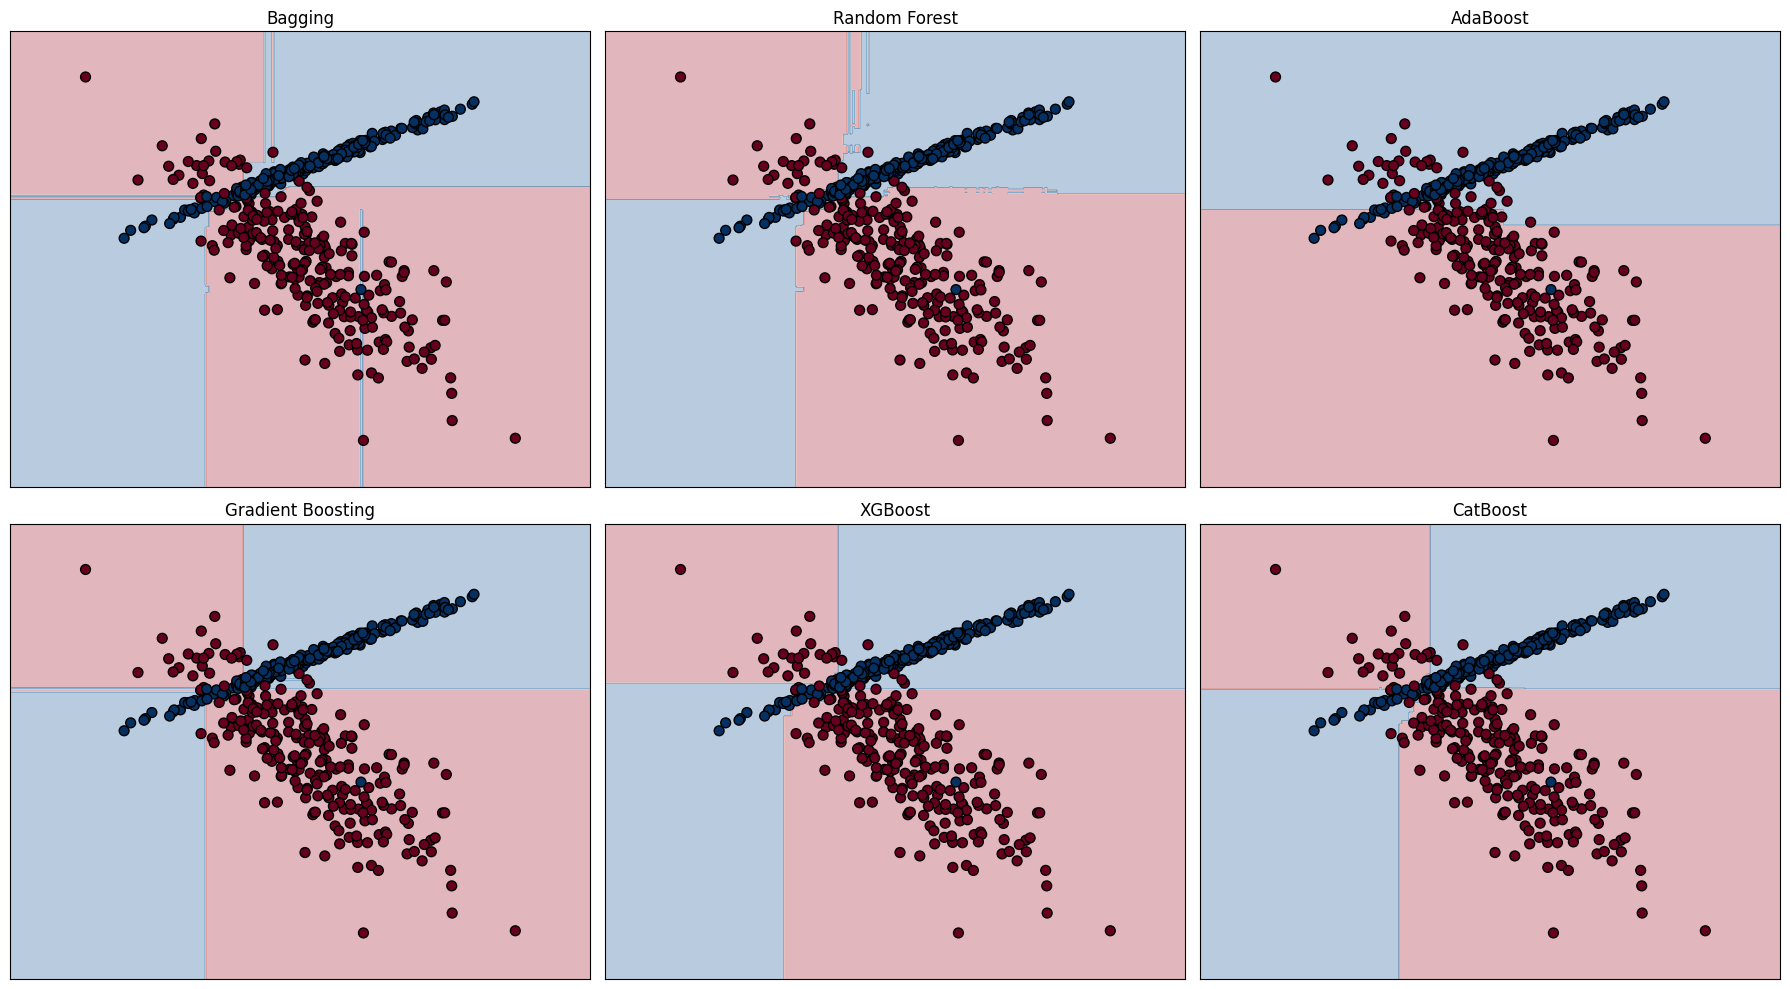


Accuracy on Noisy Data:
Bagging: 0.907
Random Forest: 0.913
AdaBoost: 0.840
Gradient Boosting: 0.907
XGBoost: 0.927
CatBoost: 0.907

Accuracy on Missing Data:
Bagging: 0.887
Random Forest: 0.887
AdaBoost: Cannot handle missing data
Gradient Boosting: Cannot handle missing data
XGBoost: 0.887
CatBoost: 0.847


In [8]:
#  Visualize decision boundaries of ensemble models.
#  Compare ensemble performance under noisy or missing data.
#  Analyze feature importance across different ensemble algorithms.



# ==============================
# Complete Ensemble Analysis Script (Corrected)
# ==============================
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
import xgboost as xgb
import warnings
warnings.filterwarnings("ignore")

# Optional CatBoost
try:
    from catboost import CatBoostClassifier
    catboost_available = True
except ImportError:
    catboost_available = False

# ------------------------------
# 1. Prepare 2D dataset
# ------------------------------
X, y = make_classification(n_samples=500, n_features=2, n_informative=2, n_redundant=0,
                           n_clusters_per_class=1, class_sep=1.0, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# ------------------------------
# 2. Define ensemble models
# ------------------------------
models = {
    "Bagging": BaggingClassifier(n_estimators=50, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=50, random_state=42),
    "AdaBoost": AdaBoostClassifier(n_estimators=50, learning_rate=1.0, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=50, learning_rate=0.1, max_depth=3, random_state=42),
    "XGBoost": xgb.XGBClassifier(n_estimators=50, learning_rate=0.1, max_depth=3, use_label_encoder=False, eval_metric='logloss', random_state=42)
}

if catboost_available:
    models["CatBoost"] = CatBoostClassifier(iterations=50, learning_rate=0.1, depth=3, verbose=0, random_state=42)

# ------------------------------
# 3. Train models and prepare report
# ------------------------------
results_list = []

for name, model in models.items():
    model.fit(X_train, y_train)

    # Test accuracy
    y_pred = model.predict(X_test)
    acc_test = accuracy_score(y_test, y_pred)

    # Train accuracy
    acc_train = accuracy_score(y_train, model.predict(X_train))

    # Overfitting check
    overfit_flag = "Possible Overfitting" if acc_train - acc_test > 0.05 else "No significant overfit"

    # Feature importance (if available)
    if hasattr(model, "feature_importances_"):
        feat_importances = model.feature_importances_
    else:
        feat_importances = None  # Use None if not available

    results_list.append({
        "Model": name,
        "Train Accuracy": round(acc_train, 3),
        "Test Accuracy": round(acc_test, 3),
        "Overfit/Underfit": overfit_flag,
        "Feature1 Importance": round(feat_importances[0],3) if feat_importances is not None else np.nan,
        "Feature2 Importance": round(feat_importances[1],3) if feat_importances is not None else np.nan
    })

df_results = pd.DataFrame(results_list)
print("\n=== Ensemble Models Report ===")
print(df_results)

# ------------------------------
# 4. Decision Boundaries (Side-by-side)
# ------------------------------
plt.figure(figsize=(18, 10))
for i, (name, model) in enumerate(models.items(), 1):
    plt.subplot(2, 3, i)
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdBu)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=50, edgecolor='k', cmap=plt.cm.RdBu)
    plt.title(name)
    plt.xticks([])
    plt.yticks([])
plt.tight_layout()
plt.show()

# ------------------------------
# 5. Accuracy under Noisy Data
# ------------------------------
X_noisy = X_test.copy()
noise_idx = np.random.choice(X_noisy.shape[0], size=int(0.2*X_noisy.shape[0]), replace=False)
X_noisy[noise_idx, 0] += np.random.normal(0, 1, len(noise_idx))
X_noisy[noise_idx, 1] += np.random.normal(0, 1, len(noise_idx))

print("\nAccuracy on Noisy Data:")
for name, model in models.items():
    try:
        acc = accuracy_score(y_test, model.predict(X_noisy))
        print(f"{name}: {acc:.3f}")
    except:
        print(f"{name}: Cannot handle noisy data")

# ------------------------------
# 6. Accuracy under Missing Data
# ------------------------------
X_missing = X_test.copy()
missing_idx = np.random.choice(X_missing.size, size=int(0.1*X_missing.size), replace=False)
X_missing.ravel()[missing_idx] = np.nan

print("\nAccuracy on Missing Data:")
for name, model in models.items():
    try:
        acc = accuracy_score(y_test, model.predict(X_missing))
        print(f"{name}: {acc:.3f}")
    except:
        print(f"{name}: Cannot handle missing data")


Heterogeneous Ensemble (VotingClassifier) Accuracy: 0.913
Homogeneous Ensemble (Bagging DT) Accuracy: 0.853
Homogeneous Ensemble (Random Forest) Accuracy: 0.840

=== Ensemble Comparison Table ===
                  Model  Test Accuracy  Train Accuracy        Overfit/Underfit
0  Heterogeneous Voting       0.913333        0.920000  No significant overfit
1            Bagging DT       0.853333        0.940000        Possible Overfit
2         Random Forest       0.840000        0.937143        Possible Overfit


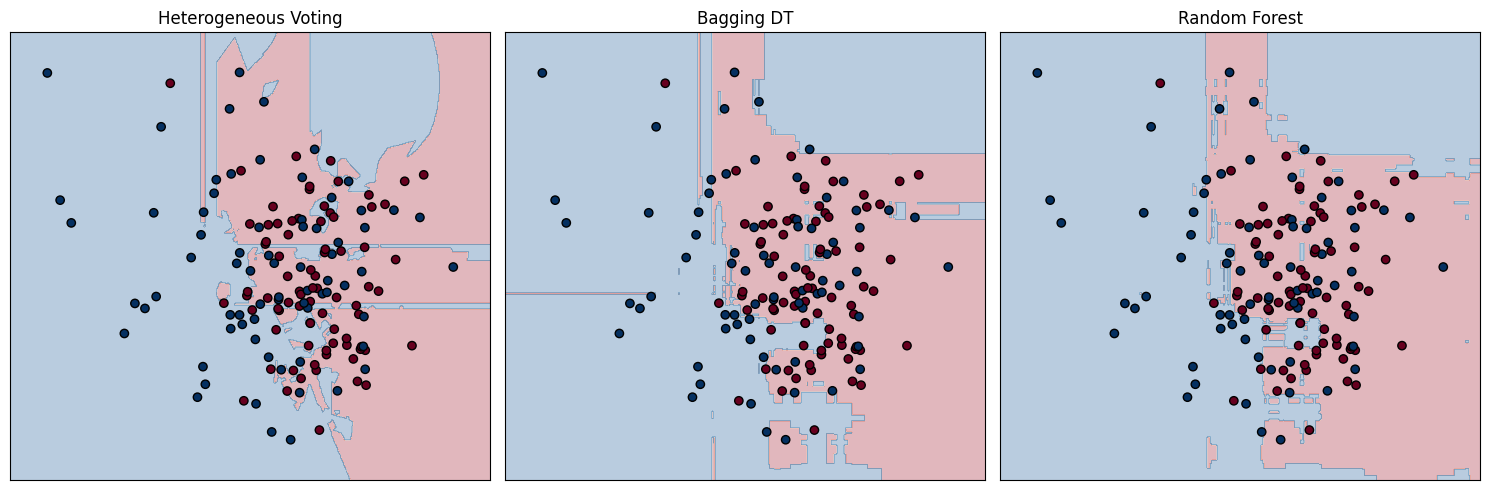

In [11]:
#Write a program to build a Heterogeneous Ensemble, combining different types of
#classifiers such as Decision Tree, K-Nearest Neighbors, Logistic Regression, and
#Support Vector Machine (SVM) using a VotingClassifier.
#Compare the results with homogeneous ensembles.
# ==============================
# Heterogeneous and Homogeneous Ensemble Comparison
# ==============================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.ensemble import VotingClassifier, BaggingClassifier, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
import warnings
warnings.filterwarnings("ignore")

# ------------------------------
# 1. Prepare dataset
# ------------------------------
X, y = make_classification(n_samples=500, n_features=10, n_informative=8, n_redundant=2,
                           n_classes=2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# ------------------------------
# 2. Define individual classifiers
# ------------------------------
clf1 = DecisionTreeClassifier(max_depth=5, random_state=42)
clf2 = KNeighborsClassifier(n_neighbors=5)
clf3 = LogisticRegression(max_iter=1000, random_state=42)
clf4 = SVC(probability=True, kernel='rbf', random_state=42)

# ------------------------------
# 3. Heterogeneous ensemble (VotingClassifier)
# ------------------------------
voting_clf = VotingClassifier(
    estimators=[('dt', clf1), ('knn', clf2), ('lr', clf3), ('svc', clf4)],
    voting='soft'  # probability-based voting
)
voting_clf.fit(X_train, y_train)
y_pred_voting = voting_clf.predict(X_test)
acc_voting = accuracy_score(y_test, y_pred_voting)
print(f"Heterogeneous Ensemble (VotingClassifier) Accuracy: {acc_voting:.3f}")

# ------------------------------
# 4. Homogeneous Ensembles
# ------------------------------
# Bagging with Decision Trees (updated for scikit-learn >=1.2)
bagging_clf = BaggingClassifier(estimator=DecisionTreeClassifier(max_depth=5),
                                n_estimators=50, random_state=42)
bagging_clf.fit(X_train, y_train)
y_pred_bagging = bagging_clf.predict(X_test)
acc_bagging = accuracy_score(y_test, y_pred_bagging)
print(f"Homogeneous Ensemble (Bagging DT) Accuracy: {acc_bagging:.3f}")

# Random Forest
rf_clf = RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42)
rf_clf.fit(X_train, y_train)
y_pred_rf = rf_clf.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)
print(f"Homogeneous Ensemble (Random Forest) Accuracy: {acc_rf:.3f}")

# ------------------------------
# 5. Summary Table
# ------------------------------
results_df = pd.DataFrame({
    'Model': ['Heterogeneous Voting', 'Bagging DT', 'Random Forest'],
    'Test Accuracy': [acc_voting, acc_bagging, acc_rf],
    'Train Accuracy': [
        accuracy_score(y_train, voting_clf.predict(X_train)),
        accuracy_score(y_train, bagging_clf.predict(X_train)),
        accuracy_score(y_train, rf_clf.predict(X_train))
    ]
})
results_df['Overfit/Underfit'] = np.where(
    results_df['Train Accuracy'] - results_df['Test Accuracy'] > 0.05,
    'Possible Overfit',
    'No significant overfit'
)
print("\n=== Ensemble Comparison Table ===")
print(results_df)

# ------------------------------
# 6. Optional: Decision Boundary Visualization (2D)
# ------------------------------
# Reduce to 2 features for visualization
X_vis, y_vis = X[:, :2], y
X_train_v, X_test_v, y_train_v, y_test_v = train_test_split(X_vis, y_vis, test_size=0.3, random_state=42)

# Refit ensembles on 2D data
voting_clf.fit(X_train_v, y_train_v)
bagging_clf.fit(X_train_v, y_train_v)
rf_clf.fit(X_train_v, y_train_v)

def plot_decision_boundary(model, X, y, title):
    x_min, x_max = X[:,0].min() - 1, X[:,0].max() + 1
    y_min, y_max = X[:,1].min() - 1, X[:,1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdBu)
    plt.scatter(X[:,0], X[:,1], c=y, edgecolor='k', cmap=plt.cm.RdBu)
    plt.title(title)
    plt.xticks([])
    plt.yticks([])

plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plot_decision_boundary(voting_clf, X_test_v, y_test_v, "Heterogeneous Voting")
plt.subplot(1,3,2)
plot_decision_boundary(bagging_clf, X_test_v, y_test_v, "Bagging DT")
plt.subplot(1,3,3)
plot_decision_boundary(rf_clf, X_test_v, y_test_v, "Random Forest")
plt.tight_layout()
plt.show()


=== Ensemble Models Comparison ===
           Model  Train Accuracy  Test Accuracy        Overfit/Underfit  \
0     Bagging DT           0.940          0.853        Possible Overfit   
1  Random Forest           0.937          0.840        Possible Overfit   
2         Voting           0.920          0.913  No significant overfit   
3       Stacking           0.920          0.940  No significant overfit   

   Training Time (s)             Interpretability  
0              0.185          High (single model)  
1              0.198  Medium (feature importance)  
2              0.055      Low (hard to interpret)  
3              0.508      Low (hard to interpret)  


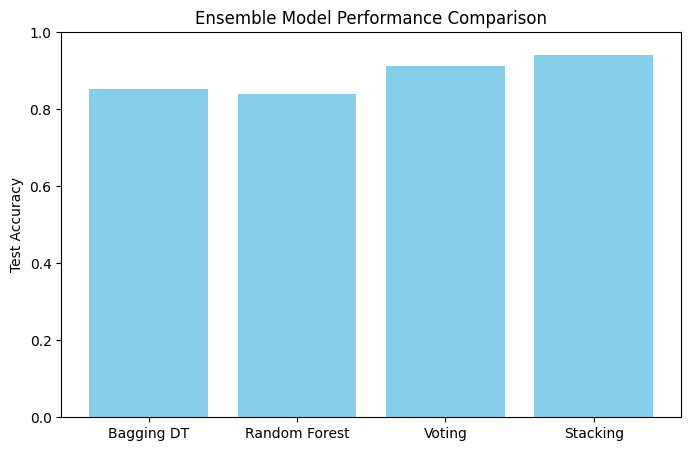

In [12]:
#Apply both homogeneous and heterogeneous ensemble techniques (Bagging, Random
#Forest, Voting, Stacking) on the same dataset.
#Prepare a summary comparing their performance, computational complexity,
#interpretability, and robustness.

# ==============================
# Ensemble Techniques Comparison
# ==============================
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, VotingClassifier, StackingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
import time
import warnings
warnings.filterwarnings("ignore")

# ------------------------------
# 1. Prepare dataset
# ------------------------------
X, y = make_classification(n_samples=500, n_features=10, n_informative=8, n_redundant=2,
                           n_classes=2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# ------------------------------
# 2. Define models
# ------------------------------
models = {}

# Homogeneous ensembles
models['Bagging DT'] = BaggingClassifier(estimator=DecisionTreeClassifier(max_depth=5),
                                         n_estimators=50, random_state=42)
models['Random Forest'] = RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42)

# Heterogeneous ensembles
clf1 = DecisionTreeClassifier(max_depth=5, random_state=42)
clf2 = KNeighborsClassifier(n_neighbors=5)
clf3 = LogisticRegression(max_iter=1000, random_state=42)
clf4 = SVC(probability=True, kernel='rbf', random_state=42)

models['Voting'] = VotingClassifier(
    estimators=[('dt', clf1), ('knn', clf2), ('lr', clf3), ('svc', clf4)],
    voting='soft'
)

models['Stacking'] = StackingClassifier(
    estimators=[('dt', clf1), ('knn', clf2), ('lr', clf3), ('svc', clf4)],
    final_estimator=LogisticRegression(),
    passthrough=True
)

# ------------------------------
# 3. Train models, measure performance & complexity
# ------------------------------
results = []

for name, model in models.items():
    start_time = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start_time

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    acc_train = accuracy_score(y_train, y_train_pred)
    acc_test = accuracy_score(y_test, y_test_pred)

    overfit_flag = "Possible Overfit" if acc_train - acc_test > 0.05 else "No significant overfit"

    # Interpretability
    if hasattr(model, "feature_importances_"):
        interpretability = "Medium (feature importance)"
    elif isinstance(model, (VotingClassifier, StackingClassifier)):
        interpretability = "Low (hard to interpret)"
    else:
        interpretability = "High (single model)"

    results.append({
        "Model": name,
        "Train Accuracy": round(acc_train, 3),
        "Test Accuracy": round(acc_test, 3),
        "Overfit/Underfit": overfit_flag,
        "Training Time (s)": round(train_time, 3),
        "Interpretability": interpretability
    })

# ------------------------------
# 4. Summary table
# ------------------------------
df_results = pd.DataFrame(results)
print("=== Ensemble Models Comparison ===")
print(df_results)

# ------------------------------
# 5. Optional: Visualize test accuracy
# ------------------------------
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.bar(df_results['Model'], df_results['Test Accuracy'], color='skyblue')
plt.ylim(0,1)
plt.ylabel("Test Accuracy")
plt.title("Ensemble Model Performance Comparison")
plt.show()
